# 05. Netflix 장기 흥행 분류 모델링

## 분석 목적

앞선 EDA에서 장기 흥행 콘텐츠는 첫 주 순위, 첫 주 시청시간, 초기 국가 확산에서 차이를 보였다.

이번 노트북에서는 **콘텐츠가 장기 흥행(`long_hit = 1`)으로 이어질지 분류하는 모델**을 만들고,
초기 성과 변수만으로 어느 정도 구분 가능한지 확인한다.

### 문제 정의

① 무엇을 예측하는가 → 장기 흥행 여부  
② X → 첫 주 순위, 첫 주 시청시간, 초기 국가 확산  
③ y → `long_hit`  
④ 문제 유형 → 이진 분류  
⑤ 모델 → Dummy Classifier → Logistic Regression → Random Forest  
⑥ 평가 → Accuracy, Precision, Recall, F1-score, ROC-AUC

### 변수 선정 원칙

이번 모델은 **콘텐츠 공개 초기 시점에 알 수 있는 변수**를 중심으로 구성한다.

- `first_rank`: 첫 진입 순위
- `log_first_week_hours`: 첫 주 시청시간의 로그 변환값
- `initial_country_reach`: 초기 국가 확산 범위

TMDB의 현재 `vote_count`, `popularity`, 현재 시즌/에피소드 수 등은 흥행 이후 값이 섞일 수 있어
이번 기본 모델에서는 제외한다.


In [1]:
# 머신러닝에 필요한 라이브러리를 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


In [2]:
# 1차 EDA에서 저장한 Netflix TV 분석 데이터를 불러오기
df = pd.read_csv("../DATA/PROCESSED/netflix_tv_analysis.csv")

print("데이터 크기:", df.shape)
print("컬럼:")
print(df.columns.tolist())

display(df.head())


데이터 크기: (159, 13)
컬럼:
['content_key', 'show_title', 'category', 'first_week', 'last_week', 'first_cumulative', 'max_cumulative', 'right_censored', 'long_hit', 'first_rank', 'first_week_hours', 'log_first_week_hours', 'initial_country_reach']


,content_key,show_title,category,first_week,last_week,first_cumulative,max_cumulative,right_censored,long_hit,first_rank,first_week_hours,log_first_week_hours,initial_country_reach
0,A Tale Dark & Grimm: Season 1,A Tale Dark & Grimm,TV (English),2021-10-17,2021-10-17,1,1,False,0,7,18730000,16.745637,19.0
1,AlRawabi School for Girls: Limited Series,AlRawabi School for Girls,TV (Non-English),2021-08-15,2021-08-29,1,3,False,0,6,11620000,16.268238,27.0
2,Alice in Borderland: Season 1,Alice in Borderland,TV (Non-English),2021-09-26,2021-10-24,1,5,False,1,8,10890000,16.203356,13.0
3,All American: Season 3,All American,TV (English),2021-08-01,2021-08-29,1,5,False,1,2,43970000,17.599018,1.0
4,Another Life: Season 2,Another Life,TV (English),2021-10-24,2021-10-24,1,1,False,0,9,15760000,16.572986,4.0


In [3]:
# target인 long_hit의 클래스 분포와 비율을 확인
target_summary = (
    df["long_hit"]
    .value_counts()
    .sort_index()
    .rename_axis("long_hit")
    .reset_index(name="count")
)

target_summary["rate"] = target_summary["count"] / len(df) * 100

display(target_summary)

print("장기 흥행 비율:", round(df["long_hit"].mean() * 100, 2), "%")


,long_hit,count,rate
0,0,115,72.327044
1,1,44,27.672956


장기 흥행 비율: 27.67 %


### 클래스 불균형 확인

`long_hit = 1`이 전체의 약 28% 수준이므로 완전히 균형 잡힌 데이터는 아니다.

따라서 Accuracy만 보면 다수 클래스인 0을 잘 맞히는 모델이 좋아 보일 수 있다.
이번 분석에서는 **F1-score와 ROC-AUC를 주요 비교 지표**로 보고,
장기 흥행 콘텐츠를 놓치지 않는지 확인하기 위해 Recall도 함께 본다.


In [4]:
# 모델 입력 변수 X와 예측 대상 y를 정의하고 결측치를 확인
feature_cols = [
    "first_rank",
    "log_first_week_hours",
    "initial_country_reach"
]

X = df[feature_cols].copy()
y = df["long_hit"].astype(int)
groups = df["show_title"]

print("X 크기:", X.shape)
print("\n결측치:")
print(X.isna().sum())


X 크기: (159, 3)

결측치:
first_rank               0
log_first_week_hours     0
initial_country_reach    1
dtype: int64


### 데이터 누수 방지

같은 작품이 여러 시즌·파트로 존재할 수 있기 때문에 단순 `train_test_split`을 사용하면
같은 `show_title`의 서로 다른 시즌이 train과 test에 동시에 들어갈 수 있다.

이를 막기 위해 **`show_title`을 그룹으로 묶어 train/test를 분리**한다.


In [5]:
# 같은 show_title이 train과 test에 동시에 들어가지 않도록 그룹 단위로 데이터를 분리
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("train 크기:", len(X_train))
print("test 크기:", len(X_test))
print("\ntrain target 분포:")
print(y_train.value_counts())
print("\ntest target 분포:")
print(y_test.value_counts())
print("\nshow_title 중복 수:", len(set(groups_train) & set(groups_test)))


train 크기: 119
test 크기: 40

train target 분포:
long_hit
0    85
1    34
Name: count, dtype: int64

test target 분포:
long_hit
0    30
1    10
Name: count, dtype: int64

show_title 중복 수: 0


In [6]:
# 비교를 위해 Dummy, Logistic Regression, Random Forest 모델을 정의
models = {
    "Dummy Classifier": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),

    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=4,
            min_samples_leaf=3,
            class_weight="balanced",
            random_state=42
        ))
    ])
}


In [7]:
# 세 모델을 학습하고 분류 평가지표를 한 표로 비교
results = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1_score": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(
    "f1_score",
    ascending=False
)

display(results_df.round(3))


,model,accuracy,precision,recall,f1_score,roc_auc
1,Logistic Regression,0.825,0.636,0.7,0.667,0.793
2,Random Forest,0.725,0.462,0.6,0.522,0.757
0,Dummy Classifier,0.750,0.000,0.0,0.000,0.500


### 모델 비교 해석

- **Dummy Classifier**: 다수 클래스만 예측하는 단순 기준선이다.
- **Logistic Regression**: 변수와 장기 흥행의 선형적인 관계를 보는 기본 분류 모델이다.
- **Random Forest**: 변수 사이의 비선형 관계까지 학습할 수 있는 비교 모델이다.

이번 데이터에서는 Logistic Regression이 기준선보다 높은 F1-score와 ROC-AUC를 보여
초기 성과 변수들이 장기 흥행 여부를 구분하는 데 실제 정보가 있음을 확인할 수 있다.

다만 데이터가 159행으로 작기 때문에 모델 간 성능 차이를 확정적으로 일반화하기보다는
**기초 모델 비교 결과**로 해석한다.


In [8]:
# F1-score가 가장 높은 Logistic Regression의 혼동행렬을 확인
best_model = models["Logistic Regression"]

y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

confusion_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

display(confusion_df)


,Predicted 0,Predicted 1
Actual 0,26,4
Actual 1,3,7


,feature,coefficient
1,log_first_week_hours,0.477468
0,first_rank,-0.294558
2,initial_country_reach,0.225265


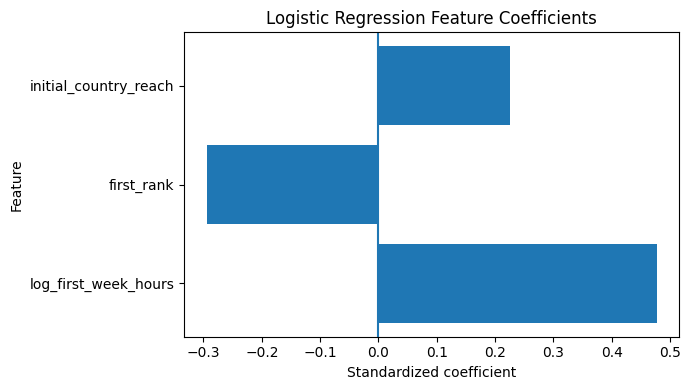

In [9]:
# Logistic Regression의 표준화된 계수를 확인해 각 변수의 방향성을 비교
logistic_model = models["Logistic Regression"].named_steps["model"]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": logistic_model.coef_[0]
}).sort_values(
    "coefficient",
    key=lambda s: s.abs(),
    ascending=False
)

display(coef_df)

plt.figure(figsize=(7, 4))
plt.barh(
    coef_df["feature"],
    coef_df["coefficient"]
)
plt.axvline(0)
plt.xlabel("Standardized coefficient")
plt.ylabel("Feature")
plt.title("Logistic Regression Feature Coefficients")
plt.tight_layout()
plt.show()


### 계수 해석 방법

Logistic Regression은 입력 변수를 표준화한 뒤 학습했기 때문에 계수의 방향과 상대적인 크기를 비교할 수 있다.

- 계수가 **양수** → 값이 커질수록 `long_hit = 1` 가능성이 높아지는 방향
- 계수가 **음수** → 값이 커질수록 `long_hit = 1` 가능성이 낮아지는 방향

특히 `first_rank`는 숫자가 작을수록 높은 순위이므로,
계수가 음수라면 **더 높은 순위로 진입할수록 장기 흥행 가능성이 높아지는 방향**으로 해석할 수 있다.


,feature,importance
1,log_first_week_hours,0.467899
2,initial_country_reach,0.290356
0,first_rank,0.241745


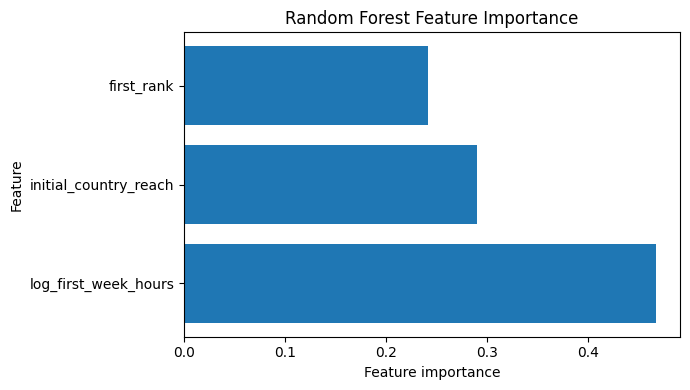

In [10]:
# Random Forest의 변수 중요도를 확인해 어떤 변수가 예측에 많이 사용됐는지 비교
rf_model = models["Random Forest"].named_steps["model"]

importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(importance_df)

plt.figure(figsize=(7, 4))
plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()


## 모델링 결과 요약

이번 모델링은 **콘텐츠 공개 초기 시점에 확인 가능한 변수만으로 장기 흥행 여부를 구분할 수 있는지** 확인하는 것을 목표로 했다.

실제 실행 결과:

- Test 데이터: 40개
- Test의 장기 흥행 콘텐츠: 10개
- 같은 `show_title`의 train/test 중복: 0개

모델 성능:

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Dummy Classifier | 0.750 | 0.000 | 0.000 | 0.000 | 0.500 |
| Logistic Regression | 0.825 | 0.636 | 0.700 | **0.667** | **0.793** |
| Random Forest | 0.725 | 0.462 | 0.600 | 0.522 | 0.757 |

Logistic Regression이 Dummy 기준선보다 분명히 높은 성능을 보였고,
Random Forest보다도 이번 test split에서는 높은 F1-score와 ROC-AUC를 기록했다.

따라서 **첫 진입 순위, 첫 주 시청시간, 초기 국가 확산 같은 초기 성과 정보가
장기 흥행 여부를 구분하는 데 의미 있는 신호로 작용할 가능성**을 확인했다.

다만 이는 인과관계를 의미하지 않으며,
초기 성과가 장기 흥행의 원인이라고 단정할 수는 없다.


## 한계 및 개선 방향

1. **데이터 수가 작음**
   - 전체 TV 분석 데이터가 159개이므로 test 결과가 분할 방식에 따라 달라질 수 있다.

2. **클래스 불균형**
   - 장기 흥행 콘텐츠가 약 28%로 적어 Accuracy만으로는 모델을 평가하기 어렵다.
   - `class_weight="balanced"`를 적용하고 F1, Recall, ROC-AUC를 함께 확인했다.

3. **TMDB 시점 누수 가능성**
   - 현재 TMDB의 `popularity`, `vote_count`, 현재 시즌·에피소드 수는 2021~2022년 당시 값이 아닐 수 있다.
   - 따라서 이번 기본 모델에서는 의도적으로 제외했다.

4. **상관관계와 인과관계 구분**
   - 초기 시청 성과와 장기 흥행 사이의 관계가 확인되더라도,
     초기 성과를 높이면 반드시 장기 흥행이 발생한다고 해석할 수는 없다.

5. **향후 개선**
   - 더 많은 기간의 Netflix 데이터를 확보
   - 시점이 고정된 콘텐츠 메타데이터 확보
   - 장르/언어/제작국가 등 정적 콘텐츠 특성 추가
   - 교차검증을 통한 모델 안정성 확인
   - Gradient Boosting 계열 모델과 추가 비교

## 비즈니스 연결

모델링 결과는 콘텐츠 자체의 성공을 보장하는 공식이라기보다,
**공개 초기 반응을 빠르게 모니터링해 장기 흥행 가능성을 조기에 판단하는 보조 지표**로 활용할 수 있다.

Lost Ark IP 애니메이션을 가정하면 공개 초기의 순위, 시청시간, 국가 확산 속도를 함께 모니터링하고,
초기 반응이 강한 시장을 중심으로 추가 마케팅·클립 확산·게임 내 연계 프로모션을 강화하는 전략을 검토할 수 있다.
